(800, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              800 non-null    int64  
 1   sex              800 non-null    int64  
 2   chest_pain_type  800 non-null    object 
 3   resting_bp       776 non-null    float64
 4   cholesterol      768 non-null    float64
 5   fasting_bs       800 non-null    int64  
 6   resting_ecg      800 non-null    object 
 7   max_hr           800 non-null    int64  
 8   exercise_angina  800 non-null    int64  
 9   oldpeak          800 non-null    float64
 10  st_slope         800 non-null    object 
 11  heart_disease    800 non-null    int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 75.1+ KB
None
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr             

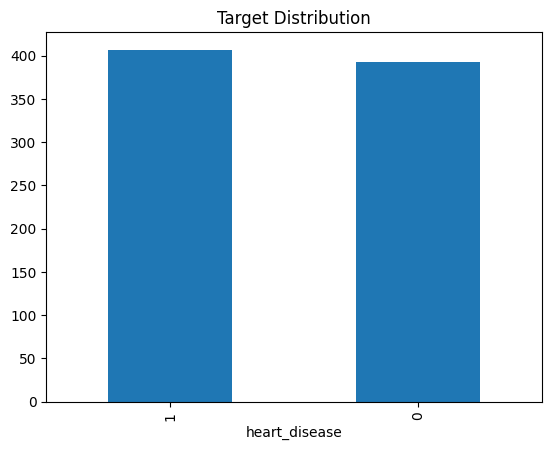

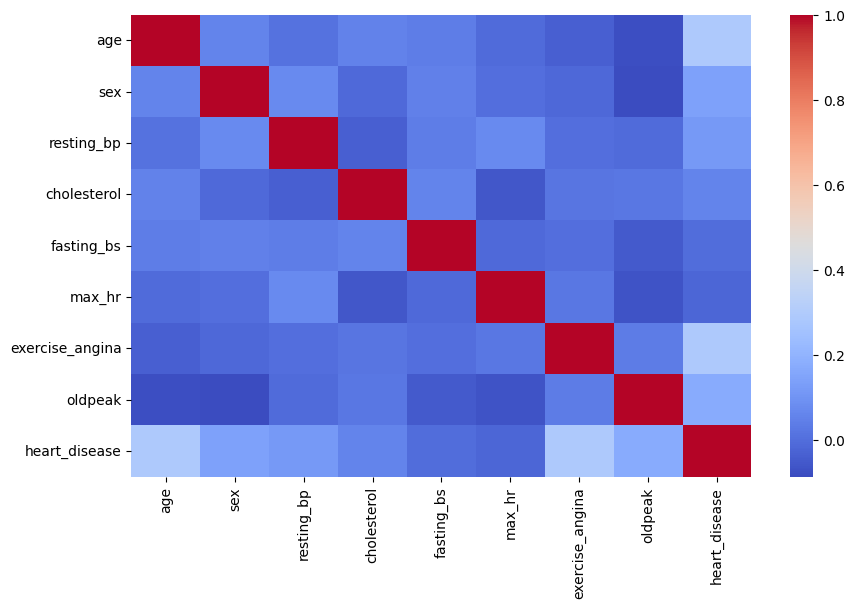

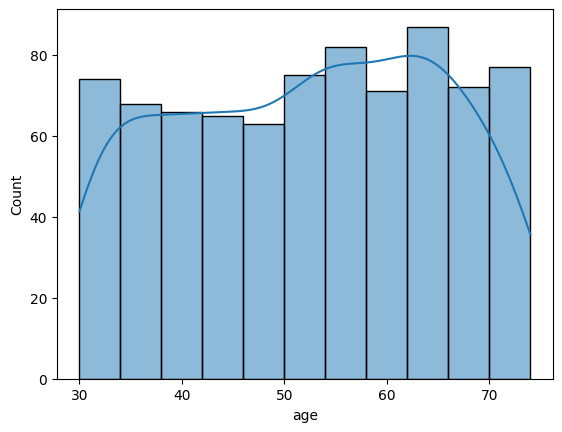

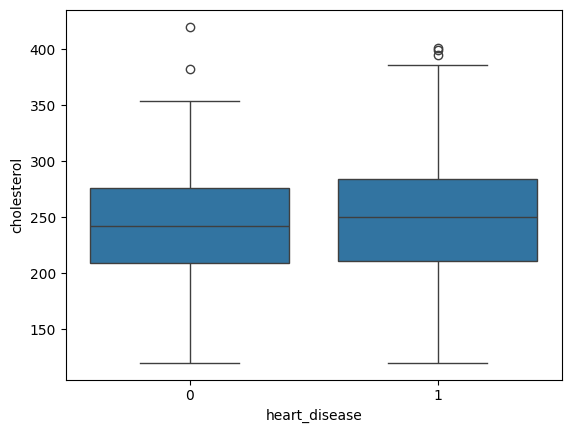


 Decision Tree
[[57 22]
 [25 56]]
              precision    recall  f1-score   support

           0       0.70      0.72      0.71        79
           1       0.72      0.69      0.70        81

    accuracy                           0.71       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.71      0.71      0.71       160


 Random Forest
[[61 18]
 [15 66]]
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


 Gradient Boosting
[[61 18]
 [19 62]]
              precision    recall  f1-score   support

           0       0.76      0.77      0.77        79
           1       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macro avg       

In [4]:
# IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# LOAD DATA
df = pd.read_csv('../data/q1_heart_disease.csv')

# INSPECTION
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df.head())

# EDA
df['heart_disease'].value_counts().plot(kind='bar')
plt.title("Target Distribution")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=['number']).corr(), cmap='coolwarm')
plt.show()

sns.histplot(df['age'], kde=True)
plt.show()

sns.boxplot(x='heart_disease', y='cholesterol', data=df)
plt.show()

# PREPROCESSING
df = df.fillna(df.median(numeric_only=True))
df = pd.get_dummies(df, drop_first=True)

X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# MODELS
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

models = {'Decision Tree': dt, 'Random Forest': rf, 'Gradient Boosting': gb}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print("\n", name)
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

# HYPERPARAMETER TUNING
param_grid = {'n_estimators': [50, 100], 'max_depth': [3, 5, 10]}

grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("\nTuned Model Performance")
print(classification_report(y_test, y_pred))